<a href="https://colab.research.google.com/github/jrebull/MIAAD_IngenieraDatos/blob/main/RDD_Practice_263483.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad Practica: RDD en PySpark**
## **Creacion, Transformaciones y Acciones**

---

**Programa:** Maestria en Inteligencia Artificial y Analitica de Datos (MIAAD)

**Materia:** Ingenieria de Datos Avanzada

**Profesor:** Dr. Vicente Garcia Jimenez

**Alumno:** Javier Augusto Rebull Saucedo

**Matricula:** 263483

**Fecha de entrega:** 24 de marzo de 2026

---

# **Objetivo**

---

Aplicar transformaciones, acciones y operaciones matematicas sobre un RDD generado a partir de datos simulados utilizando una distribucion normal aleatoria en Python.

---

# **Marco Teorico**

---

El presente marco teorico resume los conceptos fundamentales de Apache Spark y los Resilient Distributed Datasets (RDD) que sustentan la actividad practica. La informacion se basa en el material de clase del Dr. Vicente Garcia Jimenez [1]-[8], el articulo seminal de Zaharia et al. [9], la documentacion oficial de Apache Spark [10] y la definicion tecnica de IBM [11].

---

## *Apache Spark*

---

Apache Spark es un motor de procesamiento de datos distribuido disenado para ejecutar operaciones analiticas a gran escala de manera eficiente. A diferencia de MapReduce, donde cada etapa de procesamiento requiere serializar y escribir resultados intermedios en disco, Spark mantiene los datos en memoria RAM a traves de los nodos del cluster, lo que permite reutilizarlos multiples veces sin lecturas repetidas desde el almacenamiento [1][2].

Spark fue desarrollado originalmente en la Universidad de California, Berkeley, y sus creadores lo describen como un motor de computo para clusters que es compatible con el ecosistema Hadoop [2]. Segun la documentacion oficial, toda aplicacion de Spark consiste en un Driver Program que ejecuta la funcion principal del usuario y coordina operaciones paralelas sobre un cluster de computadoras [10].

La arquitectura de Spark se compone de dos elementos principales: el Driver Program, que coordina la aplicacion y decide que tareas deben realizarse, y los Workers o Executors, que procesan los datos en paralelo en los nodos del cluster [4]. El punto de entrada a Spark es el SparkContext, que establece la conexion con el gestor de recursos del cluster (YARN, Mesos o el gestor propio de Spark) y permite crear RDDs y ejecutar operaciones distribuidas [4].

---

## *Resilient Distributed Datasets (RDD)*

---

Los RDD fueron propuestos en 2012 por Zaharia et al. como una abstraccion de memoria distribuida que permite a los programadores realizar computos en memoria sobre clusters de gran escala con tolerancia a fallos [9]. Segun IBM, un RDD es una coleccion inmutable y tolerante a fallos de elementos que pueden distribuirse a traves de multiples nodos del cluster para ser procesados en paralelo [11].

El nombre RDD refleja sus tres propiedades fundamentales [3][9]:

- **Resilient (Resistente):** Si un nodo falla, Spark puede reconstruir la particion perdida utilizando el linaje (lineage), que es el historial de transformaciones aplicadas al dataset. Este mecanismo proporciona tolerancia a fallos sin necesidad de replicacion costosa de datos [9].

- **Distributed (Distribuido):** Los datos se dividen en particiones logicas que se distribuyen entre los nodos del cluster, permitiendo el procesamiento paralelo [3][10].

- **Dataset:** Es una coleccion de datos que puede contener objetos de diferentes tipos, incluyendo clases definidas por el usuario [3].

Una caracteristica esencial de los RDD es la inmutabilidad: una vez creados, su contenido no puede modificarse. Cada transformacion genera un nuevo RDD [3]. Ademas, Spark emplea evaluacion perezosa (lazy evaluation), lo que significa que las transformaciones no se ejecutan inmediatamente, sino que se registran en un grafo aciclico dirigido (DAG) hasta que una accion las dispara [4][10].

---

## *Formas de Crear un RDD*

---

Existen tres formas principales de crear un RDD en PySpark [4][10]:

1. **Paralelizar una coleccion existente:** Utilizando `sc.parallelize()` para convertir una lista de Python en un RDD distribuido. Este metodo es sencillo pero no escalable, ya que los datos deben caber en la memoria del Driver.

2. **Cargar datos desde archivos:** Utilizando `sc.textFile()` para leer archivos desde el sistema local, HDFS o sistemas como Amazon S3.

3. **Aplicar transformaciones a un RDD existente:** Cada transformacion genera un nuevo RDD a partir de otro previamente creado.

Cuando se crea un RDD, Spark divide automaticamente los datos en particiones. Cada particion representa una porcion del dataset que puede procesarse en paralelo por diferentes Executors [4].

---

## *Operaciones en RDD: Transformaciones y Acciones*

---

Las operaciones sobre RDD se clasifican en dos categorias [3][5][6][7][10]:

**Transformaciones (Lazy):** Crean un nuevo RDD a partir de otro existente, pero no se ejecutan hasta que una accion lo requiera. Las transformaciones basicas incluyen `map()`, `filter()` y `flatMap()` [5]. Ademas, Spark ofrece transformaciones de pseudo-conjuntos como `union()`, `intersection()`, `subtract()`, `distinct()` y `cartesian()`, que permiten combinar o comparar RDDs de forma similar a las operaciones de conjuntos en matematicas [6].

El termino pseudo-conjunto se utiliza porque los RDD permiten elementos duplicados, a diferencia de los conjuntos matematicos [6]. Es importante senalar que operaciones como `distinct()`, `intersection()` y `subtract()` requieren un shuffle, es decir, un intercambio de datos entre nodos, lo que puede ser costoso con grandes volumenes [6].

**Acciones (Eager):** Disparan la ejecucion del plan de transformaciones y devuelven un resultado al Driver o escriben datos en disco. Las acciones principales incluyen `collect()`, `count()`, `take()`, `first()`, `reduce()`, `takeOrdered()` y `foreach()` [7]. Al ejecutar una accion, Spark procesa todas las transformaciones pendientes registradas en el DAG [7][10].

---

# **1. Instalacion y Configuracion del Entorno**

---

Antes de trabajar con RDD es necesario verificar que PySpark este instalado en el entorno de Google Colab y posteriormente crear la SparkSession y el SparkContext.

---

## *1.1 Verificar e instalar PySpark*

---

In [1]:
# Verificar si PySpark esta instalado; si no, instalarlo
try:
    import pyspark
    print("PySpark ya esta instalado.")
    print(f"Version: {pyspark.__version__}")

except ModuleNotFoundError:
    print("PySpark no esta instalado. Instalando...")
    !pip install pyspark -q

    import pyspark
    print("Instalacion completada.")
    print(f"Version: {pyspark.__version__}")

PySpark ya esta instalado.
Version: 4.0.2


## *1.2 Crear SparkSession y SparkContext*

---

SparkSession es el punto de entrada principal para trabajar con Apache Spark. A partir de ella obtenemos el SparkContext, que es el objeto que permite crear y manipular RDDs.

---

In [2]:
from pyspark.sql import SparkSession

# Crear SparkSession
spark = SparkSession.builder \
    .appName("RDD Practice 263483") \
    .getOrCreate()

# Obtener SparkContext desde SparkSession
sc = spark.sparkContext

print("-" * 60)
print("SPARKSESSION Y SPARKCONTEXT CREADOS")
print("-" * 60)
print(f"  Aplicacion:          {sc.appName}")
print(f"  Master:              {sc.master}")
print(f"  Version de Spark:    {sc.version}")
print(f"  Version de Python:   {sc.pythonVer}")
print(f"  Default Parallelism: {sc.defaultParallelism}")
print("-" * 60)

------------------------------------------------------------
SPARKSESSION Y SPARKCONTEXT CREADOS
------------------------------------------------------------
  Aplicacion:          RDD Practice 263483
  Master:              local[*]
  Version de Spark:    4.0.2
  Version de Python:   3.12
  Default Parallelism: 2
------------------------------------------------------------


# **2. Generacion de Datos y Creacion de RDD**

---

Se genera una lista de 1000 valores numericos utilizando una distribucion normal con los siguientes parametros:

- Media (mu): 50
- Desviacion estandar (sigma): 10
- Tamano de muestra: 1000
- Semilla: 18

Posteriormente se paraleliza la lista para crear el RDD principal `rdd0`.

---

In [3]:
import numpy as np

# Parametros de la distribucion normal
MU = 50
SIGMA = 10
SAMPLE_SIZE = 1000
SEED = 18

# Fijar semilla para reproducibilidad
np.random.seed(SEED)

# Generar lista de valores con distribucion normal
data_list = np.random.normal(loc=MU, scale=SIGMA, size=SAMPLE_SIZE).tolist()

print(f"Se generaron {len(data_list)} valores.")
print(f"Primeros 5 valores: {data_list[:5]}")

Se generaron 1000 valores.
Primeros 5 valores: [50.79428443806204, 71.90202357414222, 48.65107853391729, 51.605179824548685, 54.4269784320408]


In [4]:
# Paralelizar la lista para crear rdd0
rdd0 = sc.parallelize(data_list)

print(f"RDD creado: {rdd0}")
print(f"Numero de particiones: {rdd0.getNumPartitions()}")
print(f"Total de elementos:    {rdd0.count()}")

RDD creado: ParallelCollectionRDD[0] at readRDDFromFile at PythonRDD.scala:297
Numero de particiones: 2
Total de elementos:    1000


# **3. Transformaciones Basicas**

---

Las transformaciones son operaciones perezosas (lazy) que crean un nuevo RDD a partir de otro, pero no se ejecutan hasta que se invoca una accion.

---

## *3.1 map(): Elevar al cuadrado cada elemento*

---

La transformacion `map(func)` aplica una funcion a cada elemento del RDD y devuelve un nuevo RDD con los resultados.

---

In [5]:
# Elevar al cuadrado cada elemento usando map
rdd_squared = rdd0.map(lambda x: x ** 2)

# Mostrar 5 resultados con take
print("Primeros 5 elementos elevados al cuadrado:")
print(rdd_squared.take(5))

Primeros 5 elementos elevados al cuadrado:
[2580.059331574752, 5169.900994056504, 2366.927442513388, 2663.094584724007, 2962.2959812418344]


## *3.2 filter(): Valores mayores a 50*

---

La transformacion `filter(func)` devuelve un nuevo RDD con los elementos que cumplen la condicion especificada.

---

In [6]:
# Filtrar valores mayores a 50
rdd_filtered = rdd0.filter(lambda x: x > 50)

# Imprimir 4 resultados
print("4 valores mayores a 50:")
print(rdd_filtered.take(4))
print(f"\nTotal de elementos mayores a 50: {rdd_filtered.count()}")

4 valores mayores a 50:
[50.79428443806204, 71.90202357414222, 51.605179824548685, 54.4269784320408]

Total de elementos mayores a 50: 502


# **4. Transformaciones en Pseudo-Conjuntos**

---

Los RDD no son conjuntos en sentido estricto porque permiten elementos duplicados. Sin embargo, Spark ofrece operaciones que se comportan de forma similar a las operaciones de conjuntos como union, interseccion o diferencia. Por esa razon se les llama pseudo-conjuntos.

Se generan dos nuevos conjuntos de datos (listas) de 1000 valores cada uno con distribucion normal (mu=50, sigma=10), y se convierten en `rdd1` y `rdd2`.

---

## *4.1 Crear rdd1 y rdd2*

---

Para poder aplicar operaciones de pseudo-conjuntos como intersection o subtract, los valores se redondean a enteros. De lo contrario, la probabilidad de encontrar valores identicos entre dos muestras continuas seria practicamente nula.

---

In [7]:
# Generar dos listas de 1000 valores (distribucion normal, mu=50, sigma=10)
np.random.seed(SEED)
list1 = np.random.normal(loc=MU, scale=SIGMA, size=SAMPLE_SIZE)
list1 = [round(x, 2) for x in list1]

np.random.seed(SEED + 1)
list2 = np.random.normal(loc=MU, scale=SIGMA, size=SAMPLE_SIZE)
list2 = [round(x, 2) for x in list2]

# Crear RDDs
rdd1 = sc.parallelize(list1)
rdd2 = sc.parallelize(list2)

print(f"rdd1 - Elementos: {rdd1.count()}, Primeros 5: {rdd1.take(5)}")
print(f"rdd2 - Elementos: {rdd2.count()}, Primeros 5: {rdd2.take(5)}")

rdd1 - Elementos: 1000, Primeros 5: [np.float64(50.79), np.float64(71.9), np.float64(48.65), np.float64(51.61), np.float64(54.43)]
rdd2 - Elementos: 1000, Primeros 5: [np.float64(52.21), np.float64(46.6), np.float64(44.22), np.float64(45.96), np.float64(43.97)]


## *4.2 union(): Combinar ambos RDDs*

---

La operacion `union()` combina todos los elementos de ambos RDDs en uno solo sin eliminar duplicados.

---

In [8]:
# Union de rdd1 y rdd2
rdd_union = rdd1.union(rdd2)

print("union() - Primeros 5 elementos:")
print(rdd_union.take(5))
print(f"Total de elementos en la union: {rdd_union.count()}")

union() - Primeros 5 elementos:
[np.float64(50.79), np.float64(71.9), np.float64(48.65), np.float64(51.61), np.float64(54.43)]
Total de elementos en la union: 2000


## *4.3 distinct(): Eliminar duplicados del resultado de la union*

---

La operacion `distinct()` elimina elementos duplicados y devuelve un nuevo RDD con valores unicos.

---

In [9]:
# Valores distintos de la union
rdd_distinct = rdd_union.distinct()

print("distinct() - 5 elementos ordenados:")
print(rdd_distinct.takeOrdered(5))
print(f"Total de elementos distintos: {rdd_distinct.count()}")

distinct() - 5 elementos ordenados:
[np.float64(14.33), np.float64(16.82), np.float64(17.92), np.float64(18.86), np.float64(19.1)]
Total de elementos distintos: 1531


## *4.4 intersection(): Valores comunes entre rdd1 y rdd2*

---

La operacion `intersection()` devuelve los elementos presentes en ambos RDDs, sin duplicados.

---

In [10]:
# Interseccion de rdd1 y rdd2
rdd_intersection = rdd1.intersection(rdd2)

print("intersection() - 5 elementos ordenados:")
print(rdd_intersection.takeOrdered(5))
print(f"Total de elementos en la interseccion: {rdd_intersection.count()}")

intersection() - 5 elementos ordenados:
[np.float64(27.64), np.float64(30.99), np.float64(32.62), np.float64(32.81), np.float64(33.33)]
Total de elementos en la interseccion: 197


## *4.5 subtract(): Valores en rdd1 que no estan en rdd2*

---

La operacion `subtract()` devuelve los elementos del primer RDD que no se encuentran en el segundo.

---

In [11]:
# Diferencia: rdd1 - rdd2
rdd_subtract = rdd1.subtract(rdd2)

print("subtract() - 5 elementos ordenados (rdd1 - rdd2):")
print(rdd_subtract.takeOrdered(5))
print(f"Total de elementos en rdd1 que no estan en rdd2: {rdd_subtract.count()}")

subtract() - 5 elementos ordenados (rdd1 - rdd2):
[np.float64(16.82), np.float64(17.92), np.float64(18.86), np.float64(21.22), np.float64(21.71)]
Total de elementos en rdd1 que no estan en rdd2: 770


## *4.6 cartesian(): Producto cartesiano entre ambos RDDs*

---

La operacion `cartesian()` genera todas las combinaciones posibles entre los elementos de ambos RDDs. Dado que el volumen resultante es muy grande (1000 x 1000 = 1,000,000 de pares), se aplica sobre una muestra reducida con `take(5)` de cada RDD para ilustrar el concepto.

---

In [12]:
# Producto cartesiano sobre muestras pequenas para evitar sobrecarga
rdd1_sample = sc.parallelize(rdd1.take(5))
rdd2_sample = sc.parallelize(rdd2.take(5))

rdd_cartesian = rdd1_sample.cartesian(rdd2_sample)

print("cartesian() - 5 combinaciones de ejemplo:")
for pair in rdd_cartesian.take(5):
    print(f"  {pair}")

print(f"\nTotal de combinaciones (muestra 5x5): {rdd_cartesian.count()}")

cartesian() - 5 combinaciones de ejemplo:
  (np.float64(50.79), np.float64(52.21))
  (np.float64(50.79), np.float64(46.6))
  (np.float64(71.9), np.float64(52.21))
  (np.float64(71.9), np.float64(46.6))
  (np.float64(50.79), np.float64(44.22))

Total de combinaciones (muestra 5x5): 25


## *4.7 Resumen de Pseudo-Conjuntos*

---

In [13]:
print("=" * 60)
print("RESUMEN DE OPERACIONES DE PSEUDO-CONJUNTOS")
print("=" * 60)
print(f"  rdd1 (elementos):             {rdd1.count()}")
print(f"  rdd2 (elementos):             {rdd2.count()}")
print(f"  union (elementos):            {rdd_union.count()}")
print(f"  distinct (elementos unicos):  {rdd_distinct.count()}")
print(f"  intersection (comunes):       {rdd_intersection.count()}")
print(f"  subtract rdd1-rdd2:           {rdd_subtract.count()}")
print(f"  cartesian (muestra 5x5):      {rdd_cartesian.count()}")
print("=" * 60)

RESUMEN DE OPERACIONES DE PSEUDO-CONJUNTOS
  rdd1 (elementos):             1000
  rdd2 (elementos):             1000
  union (elementos):            2000
  distinct (elementos unicos):  1531
  intersection (comunes):       197
  subtract rdd1-rdd2:           770
  cartesian (muestra 5x5):      25


# **5. Operaciones Matematicas y Estadisticas**

---

Spark ofrece acciones especificas para RDDs numericos que permiten obtener estadisticas basicas y avanzadas de forma distribuida.

---

## *5.1 Promedio, valor maximo y valor minimo*

---

In [14]:
print("=" * 60)
print("ESTADISTICAS BASICAS DE rdd0")
print("=" * 60)

mean_val = rdd0.mean()
max_val = rdd0.max()
min_val = rdd0.min()

print(f"  Promedio (mean):   {mean_val:.4f}")
print(f"  Valor maximo:      {max_val:.4f}")
print(f"  Valor minimo:      {min_val:.4f}")
print("=" * 60)

ESTADISTICAS BASICAS DE rdd0
  Promedio (mean):   49.9198
  Valor maximo:      89.4749
  Valor minimo:      16.8226


## *5.2 Varianza y desviacion estandar*

---

In [15]:
print("=" * 60)
print("MEDIDAS DE DISPERSION DE rdd0")
print("=" * 60)

variance_val = rdd0.variance()
stdev_val = rdd0.stdev()
sample_variance_val = rdd0.sampleVariance()
sample_stdev_val = rdd0.sampleStdev()

print(f"  Varianza poblacional:          {variance_val:.4f}")
print(f"  Desviacion estandar poblac.:   {stdev_val:.4f}")
print(f"  Varianza muestral:             {sample_variance_val:.4f}")
print(f"  Desviacion estandar muestral:  {sample_stdev_val:.4f}")
print("=" * 60)

MEDIDAS DE DISPERSION DE rdd0
  Varianza poblacional:          107.7805
  Desviacion estandar poblac.:   10.3817
  Varianza muestral:             107.8884
  Desviacion estandar muestral:  10.3869


## *5.3 Resumen estadistico completo con stats()*

---

La accion `stats()` retorna un objeto con todas las estadisticas en una sola llamada.

---

In [16]:
stats = rdd0.stats()

print("=" * 60)
print("RESUMEN ESTADISTICO COMPLETO (stats)")
print("=" * 60)
print(f"  Count:              {stats.count()}")
print(f"  Mean:               {stats.mean():.4f}")
print(f"  Sum:                {stats.sum():.4f}")
print(f"  Max:                {stats.max():.4f}")
print(f"  Min:                {stats.min():.4f}")
print(f"  Variance:           {stats.variance():.4f}")
print(f"  Stdev:              {stats.stdev():.4f}")
print(f"  Sample Variance:    {stats.sampleVariance():.4f}")
print(f"  Sample Stdev:       {stats.sampleStdev():.4f}")
print("=" * 60)

RESUMEN ESTADISTICO COMPLETO (stats)
  Count:              1000
  Mean:               49.9198
  Sum:                49919.7847
  Max:                89.4749
  Min:                16.8226
  Variance:           107.7805
  Stdev:              10.3817
  Sample Variance:    107.8884
  Sample Stdev:       10.3869


## *5.4 Raiz cuadrada con la biblioteca math*

---

Se utiliza `map()` junto con `math.sqrt()` para calcular la raiz cuadrada de cada elemento del RDD.

---

In [17]:
import math

# Calcular raiz cuadrada de cada elemento
rdd_sqrt = rdd0.map(lambda x: math.sqrt(abs(x)))

print("Raiz cuadrada - Primeros 5 resultados:")
for i, val in enumerate(rdd_sqrt.take(5)):
    original = rdd0.take(5)[i]
    print(f"  sqrt({original:.4f}) = {val:.4f}")

Raiz cuadrada - Primeros 5 resultados:
  sqrt(50.7943) = 7.1270
  sqrt(71.9020) = 8.4795
  sqrt(48.6511) = 6.9750
  sqrt(51.6052) = 7.1837
  sqrt(54.4270) = 7.3775


# 5.5 DASHBOARD DE RESULTADOS

/tmp/ipykernel_4473/2983061285.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('RdYlBu_r')


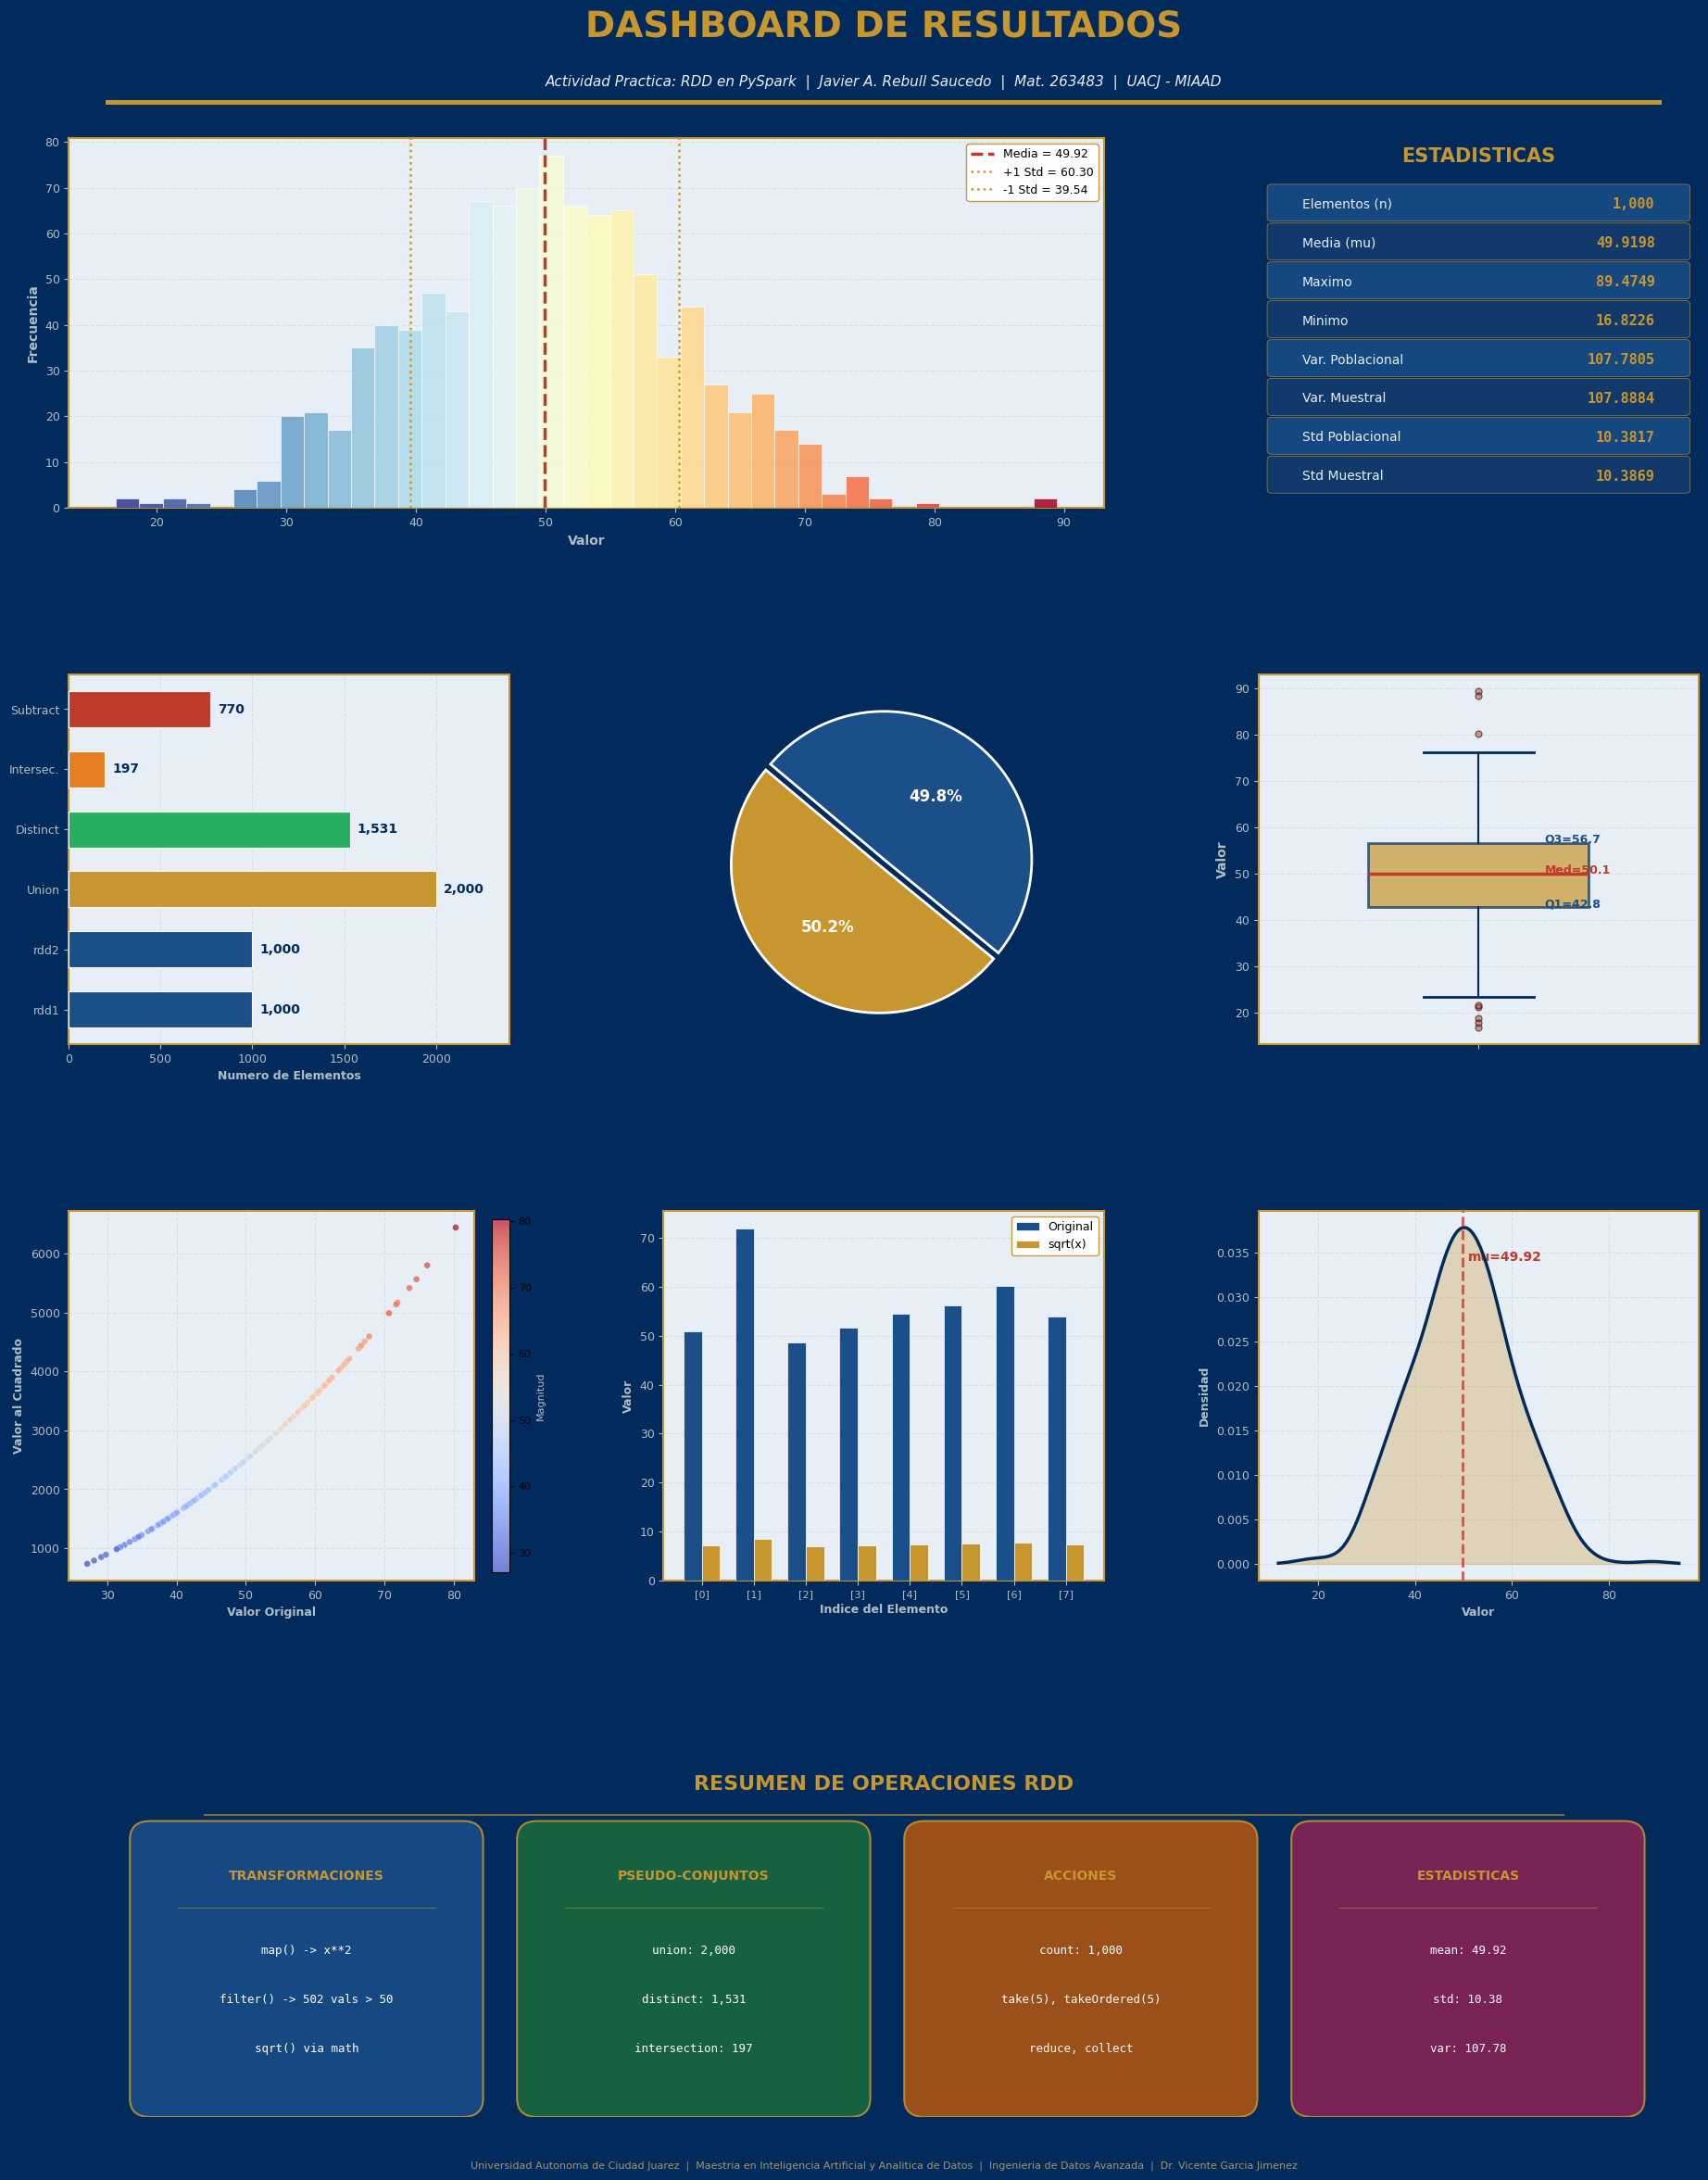


Dashboard guardado en: /content/dashboard_rdd_uacj.png


In [18]:
# ============================================================
# DASHBOARD DE RESULTADOS
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

# --- Paleta UACJ ---
UACJ_NAVY    = '#002B5C'
UACJ_GOLD    = '#C8962E'
UACJ_BLUE    = '#1B4F8A'
UACJ_LIGHT   = '#E8EEF5'
UACJ_CREAM   = '#FDF6EC'
UACJ_WHITE   = '#FFFFFF'
UACJ_GRAY    = '#B0BEC5'
UACJ_GOLD_L  = '#E8C36A'
UACJ_RED     = '#C0392B'
UACJ_GREEN   = '#27AE60'

# --- Recopilar datos del RDD (antes de cerrar Spark) ---
data_collected = rdd0.collect()
data_np = np.array(data_collected)

stats_obj    = rdd0.stats()
mean_v       = stats_obj.mean()
std_v        = stats_obj.stdev()
var_v        = stats_obj.variance()
max_v        = stats_obj.max()
min_v        = stats_obj.min()
count_v      = stats_obj.count()
sample_std_v = rdd0.sampleStdev()
sample_var_v = rdd0.sampleVariance()

count_gt50      = rdd0.filter(lambda x: x > 50).count()
count_le50      = count_v - count_gt50
union_count     = rdd_union.count()
distinct_count  = rdd_distinct.count()
inter_count     = rdd_intersection.count()
subtract_count  = rdd_subtract.count()

sqrt_sample = rdd_sqrt.take(8)
squared_sample = rdd_squared.take(8)
original_sample = rdd0.take(8)

# --- Configurar figura ---
fig = plt.figure(figsize=(20, 24), facecolor=UACJ_NAVY, dpi=100)
fig.subplots_adjust(left=0.06, right=0.94, top=0.92, bottom=0.03, hspace=0.45, wspace=0.35)

gs = GridSpec(4, 3, figure=fig, height_ratios=[1, 1, 1, 1])

# === TITULO PRINCIPAL ===
fig.text(0.5, 0.97, 'DASHBOARD DE RESULTADOS',
         fontsize=28, fontweight='bold', color=UACJ_GOLD,
         ha='center', va='center', fontfamily='sans-serif',
         path_effects=[pe.withStroke(linewidth=2, foreground=UACJ_NAVY)])
fig.text(0.5, 0.945, 'Actividad Practica: RDD en PySpark  |  Javier A. Rebull Saucedo  |  Mat. 263483  |  UACJ - MIAAD',
         fontsize=11, color=UACJ_LIGHT, ha='center', va='center', fontfamily='sans-serif', style='italic')

# Linea decorativa dorada
line_ax = fig.add_axes([0.08, 0.935, 0.84, 0.002])
line_ax.set_facecolor(UACJ_GOLD)
line_ax.set_xticks([])
line_ax.set_yticks([])
for spine in line_ax.spines.values():
    spine.set_visible(False)

def style_ax(ax, title, title_size=13):
    """Aplica estilo consistente a cada subplot."""
    ax.set_facecolor(UACJ_LIGHT)
    ax.set_title(title, fontsize=title_size, fontweight='bold',
                 color=UACJ_NAVY, pad=12, fontfamily='sans-serif')
    for spine in ax.spines.values():
        spine.set_color(UACJ_GOLD)
        spine.set_linewidth(1.5)
    ax.tick_params(colors=UACJ_GRAY, labelsize=9)

# ============================================================
# 1. HISTOGRAMA DE DISTRIBUCION (span 2 cols)
# ============================================================
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1, 'Distribucion Normal de los 1,000 Valores Generados (rdd0)', 14)

n, bins, patches = ax1.hist(data_np, bins=40, edgecolor=UACJ_WHITE, linewidth=0.5, alpha=0.85, zorder=3)

# Colorear barras con gradiente
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col_norm = plt.Normalize(bin_centers.min(), bin_centers.max())
cm = plt.cm.get_cmap('RdYlBu_r')
for c, p in zip(bin_centers, patches):
    color = cm(col_norm(c))
    p.set_facecolor(color)

# Lineas de referencia
ax1.axvline(mean_v, color=UACJ_RED, linewidth=2.5, linestyle='--', label=f'Media = {mean_v:.2f}', zorder=5)
ax1.axvline(mean_v + std_v, color=UACJ_GOLD, linewidth=1.8, linestyle=':', label=f'+1 Std = {mean_v+std_v:.2f}', zorder=5)
ax1.axvline(mean_v - std_v, color=UACJ_GOLD, linewidth=1.8, linestyle=':', label=f'-1 Std = {mean_v-std_v:.2f}', zorder=5)

ax1.set_xlabel('Valor', fontsize=10, color=UACJ_GRAY, fontweight='bold')
ax1.set_ylabel('Frecuencia', fontsize=10, color=UACJ_GRAY, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right', facecolor=UACJ_WHITE, edgecolor=UACJ_GOLD, framealpha=0.95)
ax1.grid(axis='y', alpha=0.3, color=UACJ_GRAY, linestyle='--')

# ============================================================
# 2. TARJETA DE ESTADISTICAS (panel derecho fila 1)
# ============================================================
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(UACJ_NAVY)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
for spine in ax2.spines.values():
    spine.set_visible(False)

# Titulo de tarjeta
ax2.text(5, 9.5, 'ESTADISTICAS', fontsize=15, fontweight='bold',
         color=UACJ_GOLD, ha='center', va='center', fontfamily='sans-serif')

stats_data = [
    ('Elementos (n)',   f'{count_v:,}'),
    ('Media (mu)',      f'{mean_v:.4f}'),
    ('Maximo',         f'{max_v:.4f}'),
    ('Minimo',         f'{min_v:.4f}'),
    ('Var. Poblacional', f'{var_v:.4f}'),
    ('Var. Muestral',  f'{sample_var_v:.4f}'),
    ('Std Poblacional', f'{std_v:.4f}'),
    ('Std Muestral',   f'{sample_std_v:.4f}'),
]

for i, (label, value) in enumerate(stats_data):
    y_pos = 8.2 - i * 1.05
    # Fondo alternado
    bg_color = UACJ_BLUE if i % 2 == 0 else '#163D6F'
    rect = FancyBboxPatch((0.3, y_pos - 0.35), 9.4, 0.8,
                           boxstyle="round,pad=0.1",
                           facecolor=bg_color, edgecolor=UACJ_GOLD, linewidth=0.5, alpha=0.8)
    ax2.add_patch(rect)
    ax2.text(1, y_pos, label, fontsize=10, color=UACJ_LIGHT,
             va='center', fontfamily='sans-serif')
    ax2.text(9, y_pos, value, fontsize=11, color=UACJ_GOLD,
             va='center', ha='right', fontweight='bold', fontfamily='monospace')

# ============================================================
# 3. DIAGRAMA DE BARRAS: PSEUDO-CONJUNTOS
# ============================================================
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, 'Operaciones de Pseudo-Conjuntos')

ops_labels = ['rdd1', 'rdd2', 'Union', 'Distinct', 'Intersec.', 'Subtract']
ops_values = [rdd1.count(), rdd2.count(), union_count, distinct_count, inter_count, subtract_count]
ops_colors = [UACJ_BLUE, UACJ_BLUE, UACJ_GOLD, UACJ_GREEN, '#E67E22', UACJ_RED]

bars = ax3.barh(ops_labels, ops_values, color=ops_colors, edgecolor=UACJ_WHITE, linewidth=0.8, height=0.6, zorder=3)

for bar, val in zip(bars, ops_values):
    ax3.text(bar.get_width() + max(ops_values)*0.02, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold', color=UACJ_NAVY)

ax3.set_xlabel('Numero de Elementos', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax3.grid(axis='x', alpha=0.3, color=UACJ_GRAY, linestyle='--')
ax3.set_xlim(0, max(ops_values) * 1.2)

# ============================================================
# 4. PIE CHART: VALORES > 50 vs <= 50
# ============================================================
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, 'Distribucion: Valores > 50 vs <= 50')

pie_vals = [count_gt50, count_le50]
pie_labels = [f'> 50\n({count_gt50})', f'<= 50\n({count_le50})']
pie_colors = [UACJ_GOLD, UACJ_BLUE]
explode = (0.05, 0)

wedges, texts, autotexts = ax4.pie(
    pie_vals, labels=pie_labels, colors=pie_colors, explode=explode,
    autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11, 'color': UACJ_NAVY},
    wedgeprops={'edgecolor': UACJ_WHITE, 'linewidth': 2},
    pctdistance=0.55
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
    at.set_color(UACJ_WHITE)

# ============================================================
# 5. BOX PLOT
# ============================================================
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5, 'Diagrama de Caja (rdd0)')

bp = ax5.boxplot(data_np, vert=True, patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor=UACJ_GOLD, color=UACJ_NAVY, linewidth=2, alpha=0.7),
                 medianprops=dict(color=UACJ_RED, linewidth=2.5),
                 whiskerprops=dict(color=UACJ_NAVY, linewidth=1.5),
                 capprops=dict(color=UACJ_NAVY, linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=UACJ_RED, markersize=5, alpha=0.5))

ax5.set_ylabel('Valor', fontsize=10, color=UACJ_GRAY, fontweight='bold')
ax5.set_xticklabels(['rdd0'], fontsize=11, fontweight='bold', color=UACJ_NAVY)
ax5.grid(axis='y', alpha=0.3, color=UACJ_GRAY, linestyle='--')

# Anotaciones en box plot
q1 = np.percentile(data_np, 25)
q3 = np.percentile(data_np, 75)
median = np.median(data_np)
ax5.annotate(f'Q3={q3:.1f}', xy=(1.15, q3), fontsize=9, color=UACJ_BLUE, fontweight='bold')
ax5.annotate(f'Med={median:.1f}', xy=(1.15, median), fontsize=9, color=UACJ_RED, fontweight='bold')
ax5.annotate(f'Q1={q1:.1f}', xy=(1.15, q1), fontsize=9, color=UACJ_BLUE, fontweight='bold')

# ============================================================
# 6. SCATTER: ORIGINAL vs CUADRADO
# ============================================================
ax6 = fig.add_subplot(gs[2, 0])
style_ax(ax6, 'Relacion: Valor Original vs Cuadrado')

sample_size_scatter = min(200, len(data_np))
scatter_x = data_np[:sample_size_scatter]
scatter_y = scatter_x ** 2

sc_plot = ax6.scatter(scatter_x, scatter_y, c=scatter_x, cmap='coolwarm',
                      s=25, alpha=0.7, edgecolors=UACJ_WHITE, linewidth=0.3, zorder=3)
ax6.set_xlabel('Valor Original', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax6.set_ylabel('Valor al Cuadrado', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax6.grid(alpha=0.3, color=UACJ_GRAY, linestyle='--')

cbar = plt.colorbar(sc_plot, ax=ax6, fraction=0.04, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Magnitud', fontsize=8, color=UACJ_GRAY)

# ============================================================
# 7. BARRAS: ORIGINAL vs SQRT (muestra de 8)
# ============================================================
ax7 = fig.add_subplot(gs[2, 1])
style_ax(ax7, 'Comparacion: Original vs Raiz Cuadrada')

x_pos = np.arange(len(original_sample))
width = 0.35

bars1 = ax7.bar(x_pos - width/2, original_sample, width, label='Original',
                color=UACJ_BLUE, edgecolor=UACJ_WHITE, linewidth=0.5, zorder=3)
bars2 = ax7.bar(x_pos + width/2, sqrt_sample, width, label='sqrt(x)',
                color=UACJ_GOLD, edgecolor=UACJ_WHITE, linewidth=0.5, zorder=3)

ax7.set_xlabel('Indice del Elemento', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax7.set_ylabel('Valor', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax7.set_xticks(x_pos)
ax7.set_xticklabels([f'[{i}]' for i in range(len(original_sample))], fontsize=8)
ax7.legend(fontsize=9, facecolor=UACJ_WHITE, edgecolor=UACJ_GOLD, framealpha=0.95)
ax7.grid(axis='y', alpha=0.3, color=UACJ_GRAY, linestyle='--')

# ============================================================
# 8. KDE + HISTOGRAMA ELEGANTE
# ============================================================
ax8 = fig.add_subplot(gs[2, 2])
style_ax(ax8, 'Densidad de Probabilidad (KDE)')

from scipy.stats import gaussian_kde

kde = gaussian_kde(data_np, bw_method=0.3)
x_kde = np.linspace(data_np.min() - 5, data_np.max() + 5, 300)
y_kde = kde(x_kde)

ax8.fill_between(x_kde, y_kde, alpha=0.3, color=UACJ_GOLD, zorder=3)
ax8.plot(x_kde, y_kde, color=UACJ_NAVY, linewidth=2.5, zorder=4)
ax8.axvline(mean_v, color=UACJ_RED, linewidth=2, linestyle='--', alpha=0.8, zorder=5)
ax8.text(mean_v + 1, max(y_kde) * 0.9, f'mu={mean_v:.2f}', fontsize=10,
         color=UACJ_RED, fontweight='bold')

ax8.set_xlabel('Valor', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax8.set_ylabel('Densidad', fontsize=9, color=UACJ_GRAY, fontweight='bold')
ax8.grid(alpha=0.3, color=UACJ_GRAY, linestyle='--')

# ============================================================
# 9. RESUMEN VISUAL DE OPERACIONES RDD (fila 4 span completo)
# ============================================================
ax9 = fig.add_subplot(gs[3, :])
ax9.set_facecolor(UACJ_NAVY)
ax9.set_xlim(0, 12)
ax9.set_ylim(0, 3)
ax9.axis('off')
for spine in ax9.spines.values():
    spine.set_visible(False)

ax9.text(6, 2.7, 'RESUMEN DE OPERACIONES RDD', fontsize=16, fontweight='bold',
         color=UACJ_GOLD, ha='center', va='center', fontfamily='sans-serif')

# Linea decorativa
ax9.plot([1, 11], [2.45, 2.45], color=UACJ_GOLD, linewidth=1.5, alpha=0.6)

cards = [
    ('TRANSFORMACIONES', ['map() -> x**2', f'filter() -> {count_gt50} vals > 50', 'sqrt() via math'], UACJ_BLUE),
    ('PSEUDO-CONJUNTOS', [f'union: {union_count:,}', f'distinct: {distinct_count:,}', f'intersection: {inter_count:,}'], '#1A6B3C'),
    ('ACCIONES', [f'count: {count_v:,}', f'take(5), takeOrdered(5)', f'reduce, collect'], '#B7560E'),
    ('ESTADISTICAS', [f'mean: {mean_v:.2f}', f'std: {std_v:.2f}', f'var: {var_v:.2f}'], '#8E2252'),
]

card_width = 2.3
start_x = 0.6
for i, (title, items, color) in enumerate(cards):
    cx = start_x + i * 2.85
    # Fondo de tarjeta
    rect = FancyBboxPatch((cx, 0.15), card_width, 2.1,
                           boxstyle="round,pad=0.15",
                           facecolor=color, edgecolor=UACJ_GOLD,
                           linewidth=1.5, alpha=0.85)
    ax9.add_patch(rect)
    # Titulo
    ax9.text(cx + card_width/2, 1.95, title, fontsize=10, fontweight='bold',
             color=UACJ_GOLD, ha='center', va='center', fontfamily='sans-serif')
    # Linea separadora
    ax9.plot([cx + 0.2, cx + card_width - 0.2], [1.7, 1.7],
             color=UACJ_GOLD, linewidth=0.8, alpha=0.5)
    # Items
    for j, item in enumerate(items):
        ax9.text(cx + card_width/2, 1.35 - j * 0.4, item,
                 fontsize=9, color=UACJ_WHITE, ha='center', va='center',
                 fontfamily='monospace')

# --- Footer ---
fig.text(0.5, 0.008,
         'Universidad Autonoma de Ciudad Juarez  |  Maestria en Inteligencia Artificial y Analitica de Datos  |  Ingenieria de Datos Avanzada  |  Dr. Vicente Garcia Jimenez',
         fontsize=8, color=UACJ_GOLD_L, ha='center', va='center', fontfamily='sans-serif', alpha=0.7)

plt.savefig('/content/dashboard_rdd_uacj.png', dpi=150, bbox_inches='tight',
            facecolor=UACJ_NAVY, edgecolor='none')
plt.show()
print("\nDashboard guardado en: /content/dashboard_rdd_uacj.png")

# **6. Finalizacion de la SparkSession**

---

Es buena practica detener la SparkSession al terminar el procesamiento para liberar los recursos.

---

In [19]:
spark.stop()
print("SparkSession finalizada correctamente.")

SparkSession finalizada correctamente.


# **Referencias**

---

[1] V. Garcia Jimenez, "Sesion16PysparkRDD.ipynb," Cuaderno de Google Colab, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://colab.research.google.com/drive/1wHC_94anQIgKqS1E8gLZGIHtLGQPcfIA?usp=sharing

[2] V. Garcia Jimenez, "PySpark - Python para Spark: Introduccion," Video 01, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/07trJZ5KnSA

[3] V. Garcia Jimenez, "PySpark: Introduccion a RDD," Video 02, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/hxIr1OwM494

[4] V. Garcia Jimenez, "PySpark: Creacion de RDD," Video 03, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/5kTK4hwYdSg

[5] V. Garcia Jimenez, "PySpark: Transformaciones Basicas en RDD," Video 04, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/z1vYbWTl1S4

[6] V. Garcia Jimenez, "PySpark: Transformaciones con Pseudo-Conjuntos," Video 05, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/skB1u_oHdiY

[7] V. Garcia Jimenez, "PySpark: Acciones en RDD," Video 06, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/I5UmEjtMmdM

[8] V. Garcia Jimenez, "PySpark: Operaciones en RDD Numericos," Video 07, Ingenieria de Datos Avanzada, Maestria en Inteligencia Artificial y Analitica de Datos, Universidad Autonoma de Ciudad Juarez, 2026. [En linea]. Disponible: https://youtu.be/f5dzM2F6S9U

[9] M. Zaharia, M. Chowdhury, T. Das, A. Dave, J. Ma, M. McCauley, M. J. Franklin, S. Shenker e I. Stoica, "Resilient Distributed Datasets: A Fault-Tolerant Abstraction for In-Memory Cluster Computing," en *9th USENIX Symposium on Networked Systems Design and Implementation (NSDI 12)*, San Jose, CA, 2012, pp. 15-28. [En linea]. Disponible: https://www.usenix.org/conference/nsdi12/technical-sessions/presentation/zaharia

[10] Apache Software Foundation, "RDD Programming Guide," Spark 4.0.0 Documentation, 2025. [En linea]. Disponible: https://spark.apache.org/docs/latest/rdd-programming-guide.html

[11] IBM, "What Is a Resilient Distributed Dataset (RDD)?," IBM Think, 2025. [En linea]. Disponible: https://www.ibm.com/think/topics/resilient-distributed-dataset

[12] Apache Software Foundation, "pyspark.RDD," PySpark 4.0.0 API Documentation, 2025. [En linea]. Disponible: https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.RDD.html

---